In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

from pathlib import Path

ROOT = Path("/home/py/groundwater/")
DATA = ROOT / 'data'
GOWN = DATA / 'gown'

In [ ]:
df = pd.read_csv(GOWN / 'combined_absval_20052024_filled.csv', parse_dates=[0], index_col=0)
df = df.sort_index(axis=1)
df_m = df.resample("MS").mean()
df_m.index = df_m.index + pd.Timedelta(days=14)
df_m.columns = df_m.columns.astype(int)

brac = pd.read_csv(DATA / 'bow_valley' / 'stream' / 'cr_flow.csv', index_col=1, parse_dates=[1])
brac = brac.drop(columns=['Unnamed: 0'])
brac = brac.resample("MS").mean()
brac.index = brac.index + pd.Timedelta(days=14)
brac = brac.loc['2005':]
brac = brac.squeeze()


krns = pd.read_csv(DATA / 'bow_valley' / 'stream' / 'krns.csv', index_col=0, parse_dates=[0])
krns.index = krns.index + pd.Timedelta(days=14)
krns = krns.squeeze()

ws = [931, 301, 303, 386, 305, 764, 760, 759, 364]

In [51]:
brac_e = pd.read_csv(DATA / 'bow_valley' / 'stream' / 'cr.csv', usecols=[0,2], parse_dates=[0], index_col=0)
brac_e = brac_e.squeeze()

In [3]:
rows = {}
for w in ws:
    r = mk.correlated_seasonal_test(df_m[w].values, period=12)
    rows[w] = {"tau": r.Tau, "slope_m_yr": r.slope, "p": r.p, "verdict": r.trend}

smk = pd.DataFrame(rows).T
smk[["tau", "slope_m_yr", "p"]] = smk[["tau", "slope_m_yr", "p"]].astype(float)

print(smk["verdict"].value_counts())

verdict
decreasing    7
increasing    1
no trend      1
Name: count, dtype: int64


In [54]:
rivs = {}

r = mk.correlated_seasonal_test(brac.values, period=12)
rivs['BRatC'] = {"tau": r.Tau, "slope_m3_yr": r.slope, "p": r.p, "verdict": r.trend}

r = mk.correlated_seasonal_test(krns.values, period=12)
rivs['KRnS'] = {"tau": r.Tau, "slope_m3_yr": r.slope, "p": r.p, "verdict": r.trend}

rivs = pd.DataFrame(rivs).T
rivs

,tau,slope_m3_yr,p,verdict
BRatC,-0.281676,-0.501956,0.001562,decreasing
KRnS,0.021212,0.024877,0.827259,no trend


In [4]:
sen = smk.sort_values("slope_m_yr")
print("strongest declines:\n", sen[["slope_m_yr", "tau", "p"]].head(5))
print("\nstrongest rises:\n", sen[["slope_m_yr", "tau", "p"]].tail(5))
print(f"\n{(smk['p'] < 0.05).sum()} of {len(smk)} 'significant' at p<0.05")

strongest declines:
      slope_m_yr       tau         p
303   -0.044508 -0.325439  0.004460
764   -0.038566 -0.336842  0.008247
305   -0.031324 -0.381579  0.000129
759   -0.016055 -0.214035  0.039079
364   -0.014041 -0.335965  0.024932

strongest rises:
      slope_m_yr       tau         p
364   -0.014041 -0.335965  0.024932
386   -0.013536 -0.450000  0.000070
301   -0.012168 -0.276316  0.015159
760   -0.001375 -0.022807  0.829248
931    0.035785  0.276316  0.013236

8 of 9 'significant' at p<0.05


In [5]:
smk.sort_values("slope_m_yr")

,tau,slope_m_yr,p,verdict
303,-0.325439,-0.044508,0.004460,decreasing
764,-0.336842,-0.038566,0.008247,decreasing
305,-0.381579,-0.031324,0.000129,decreasing
759,-0.214035,-0.016055,0.039079,decreasing
364,-0.335965,-0.014041,0.024932,decreasing
386,-0.450000,-0.013536,0.000070,decreasing
301,-0.276316,-0.012168,0.015159,decreasing
760,-0.022807,-0.001375,0.829248,no trend
931,0.276316,0.035785,0.013236,increasing


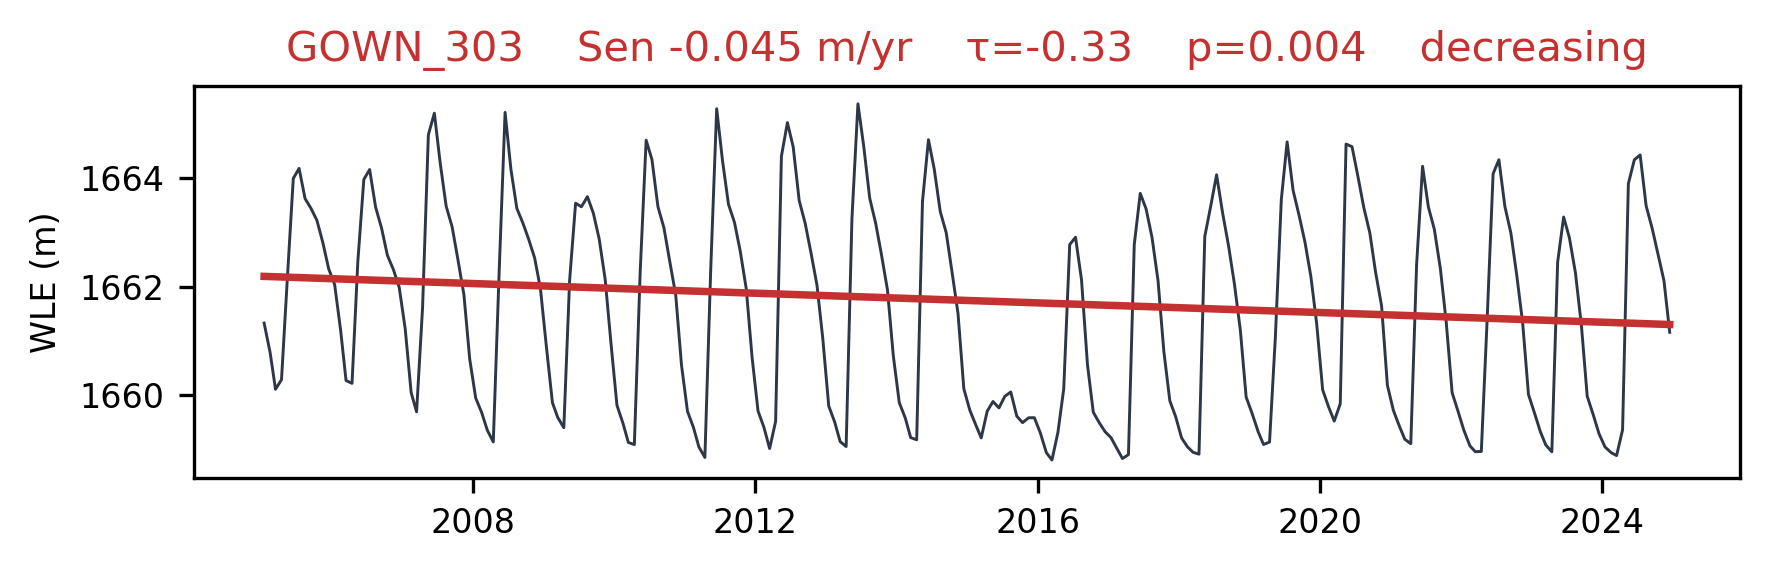

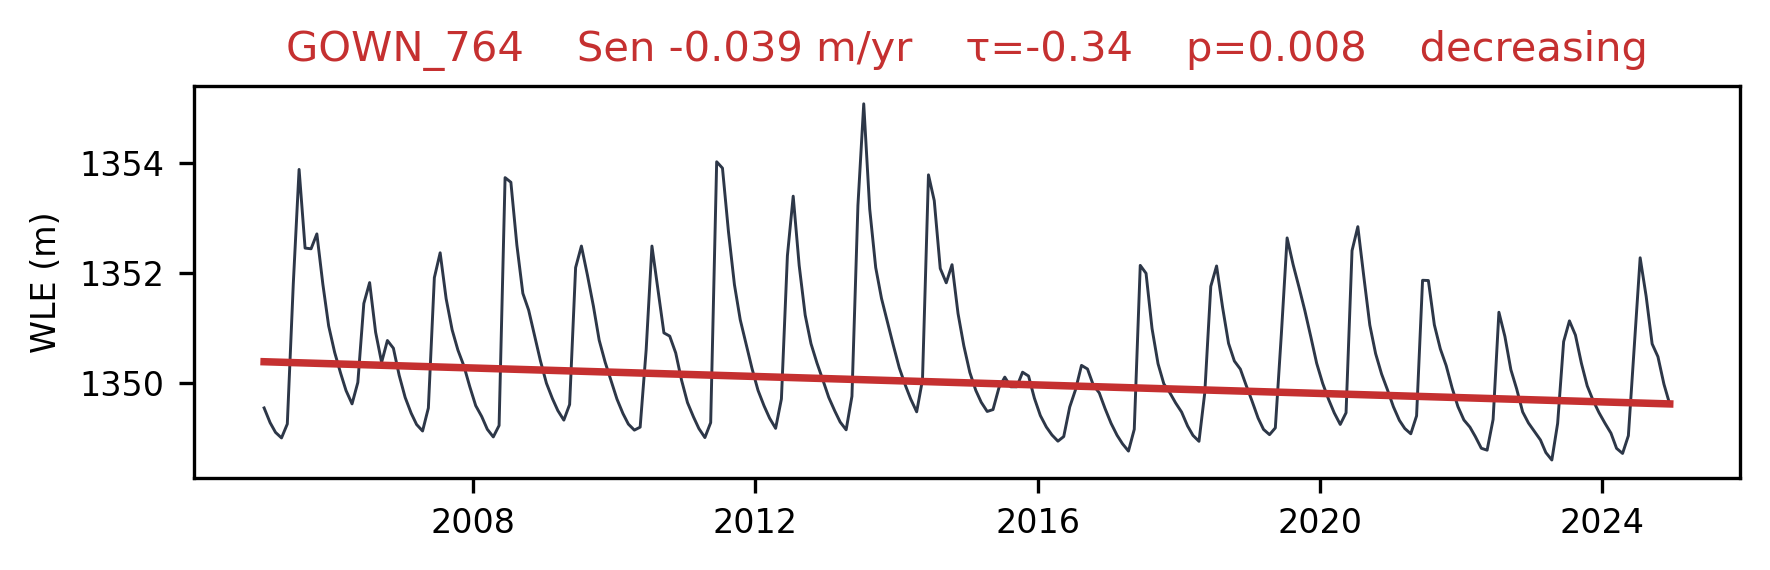

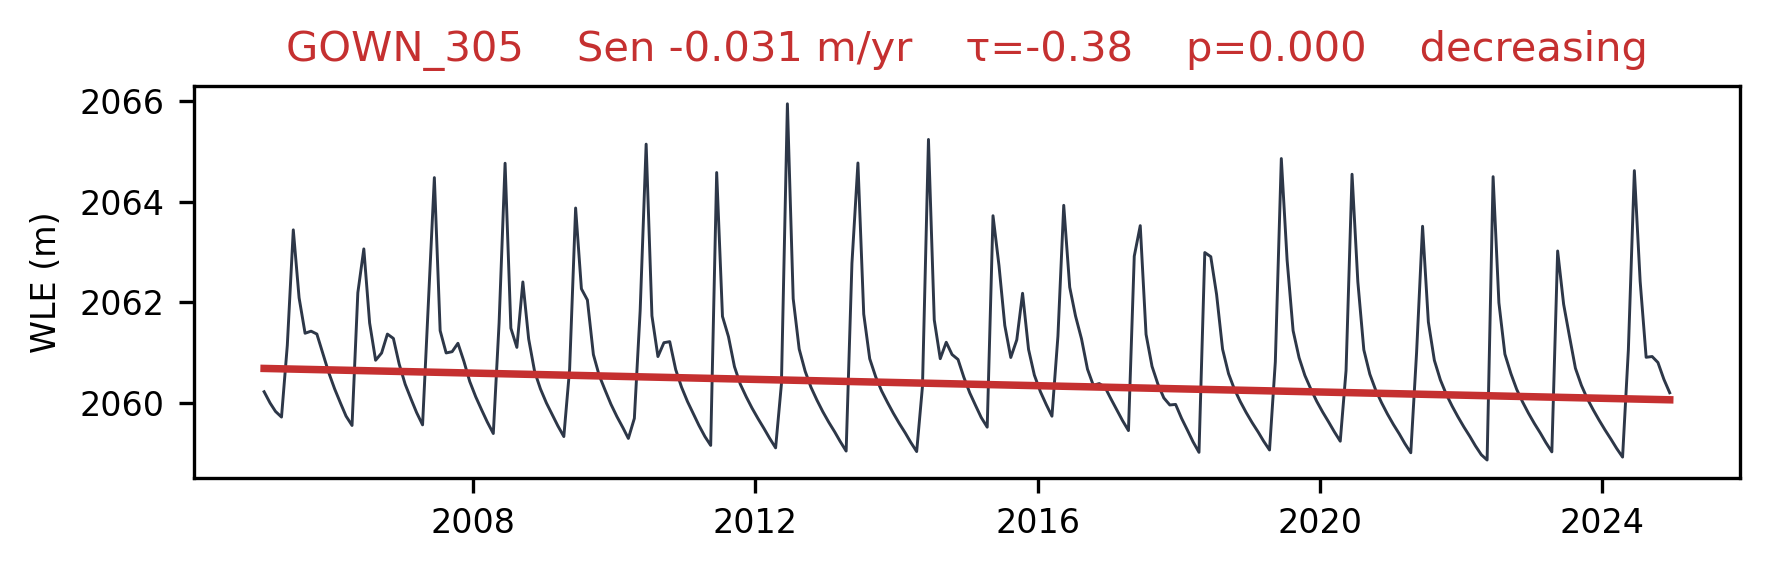

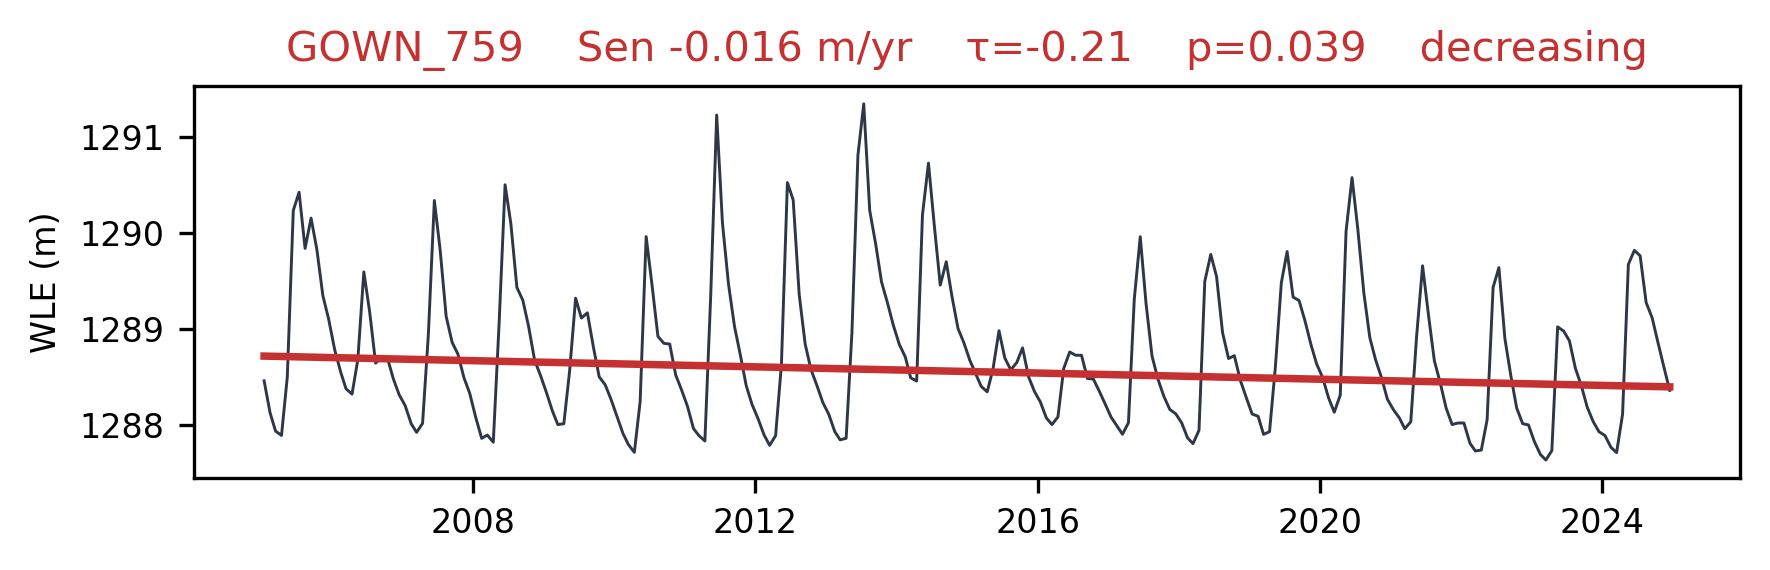

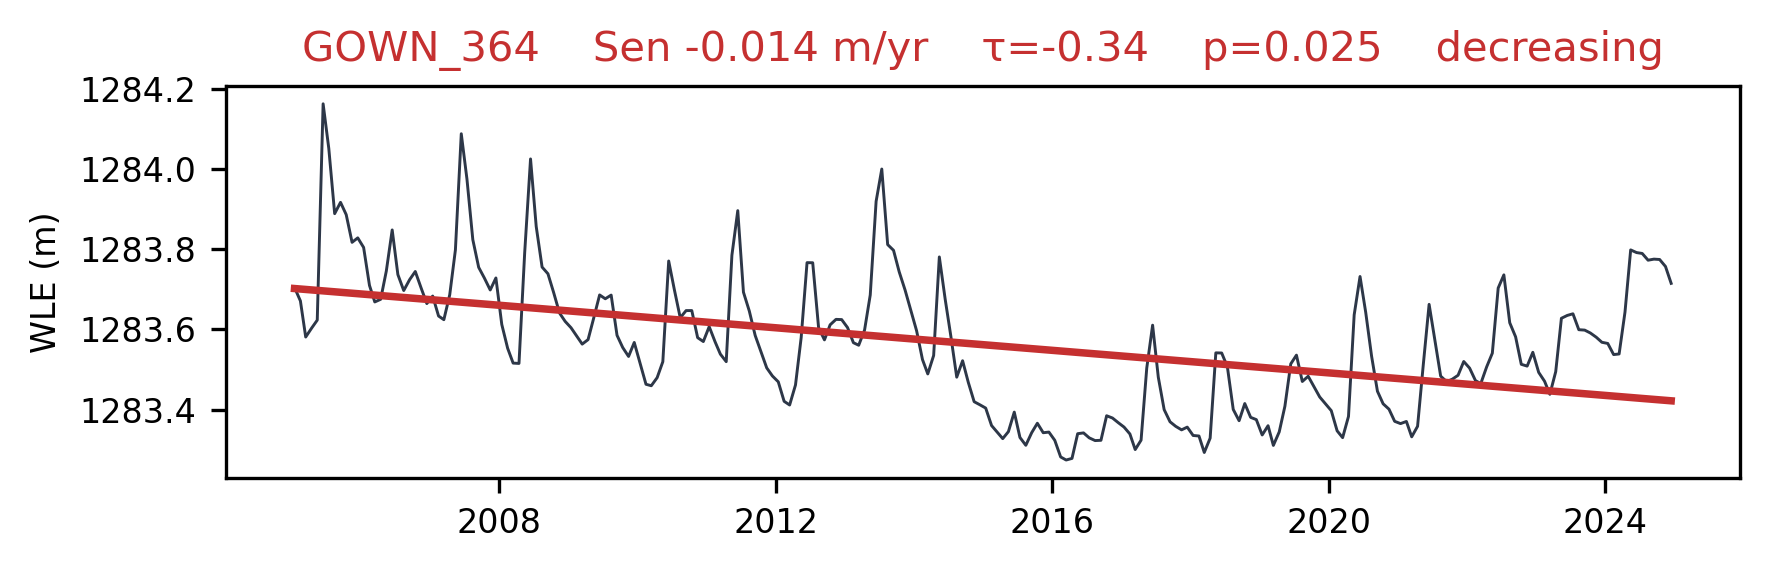

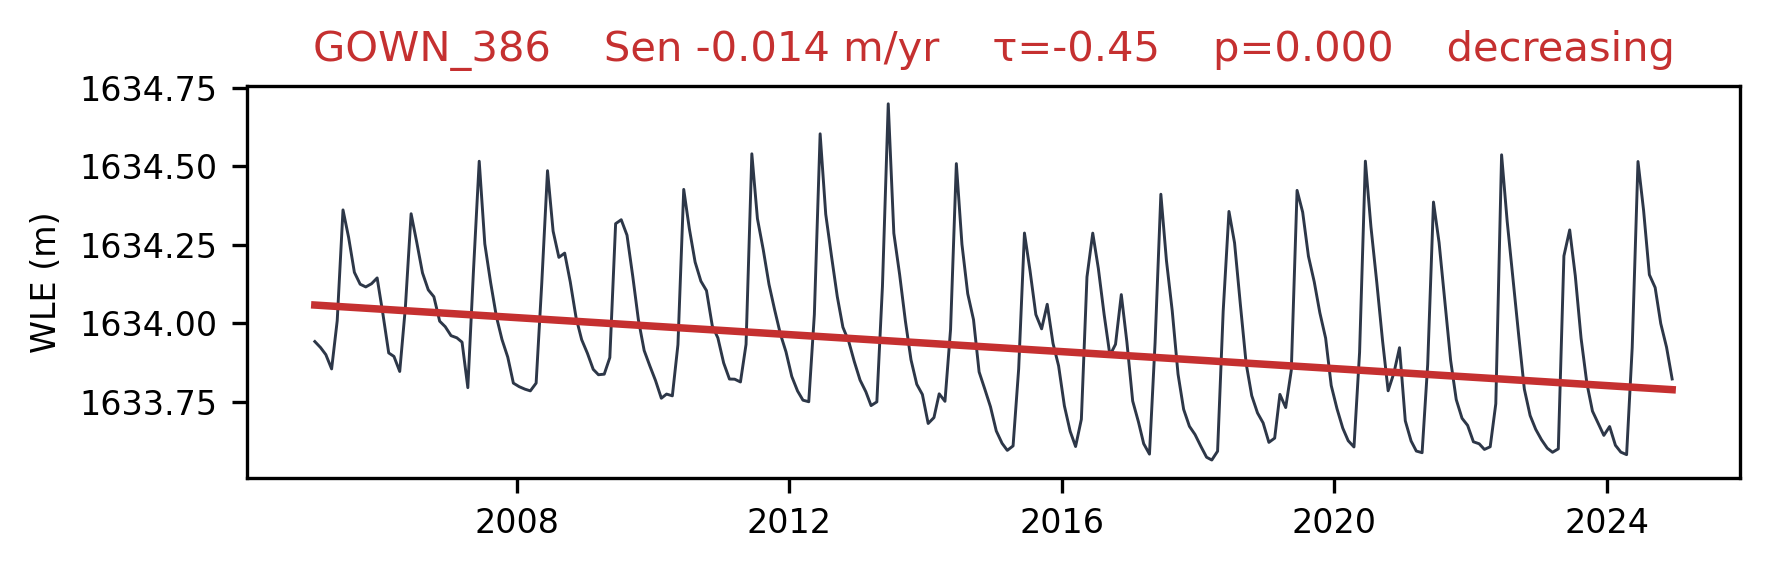

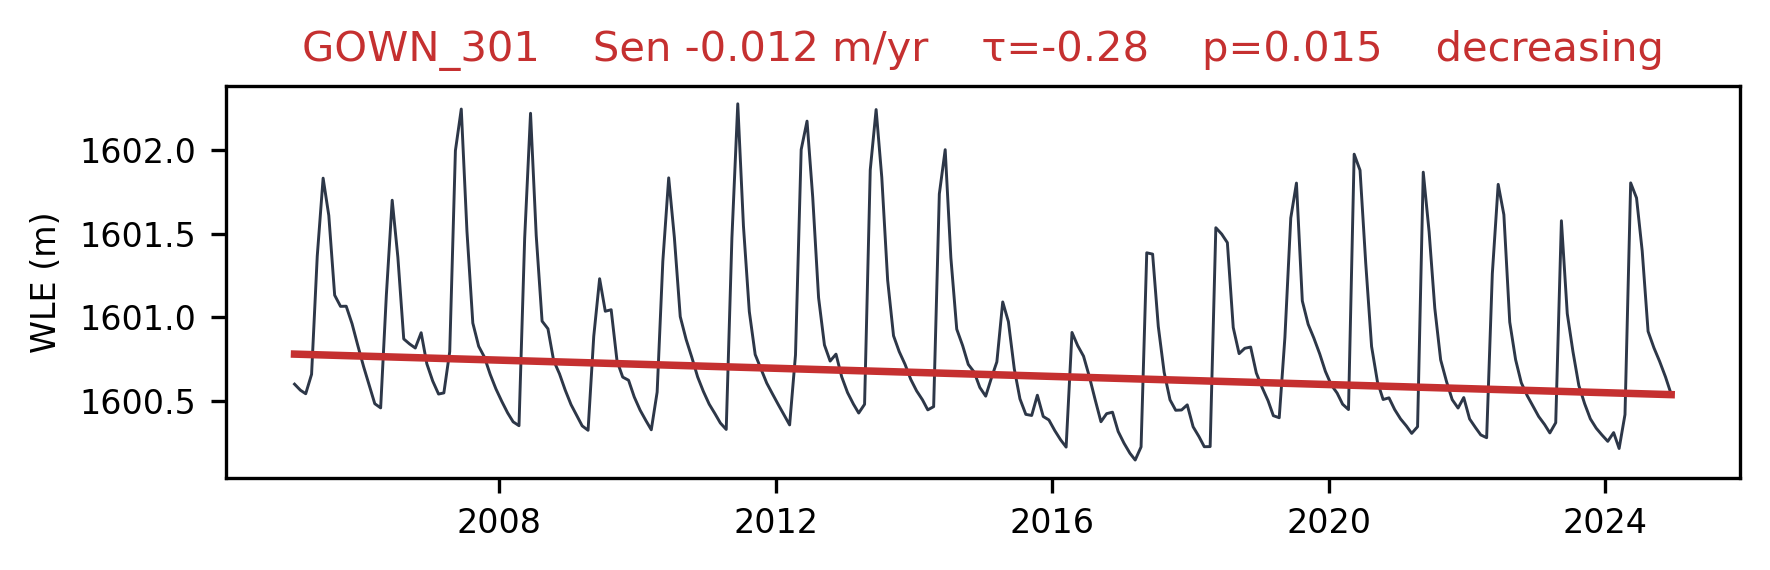

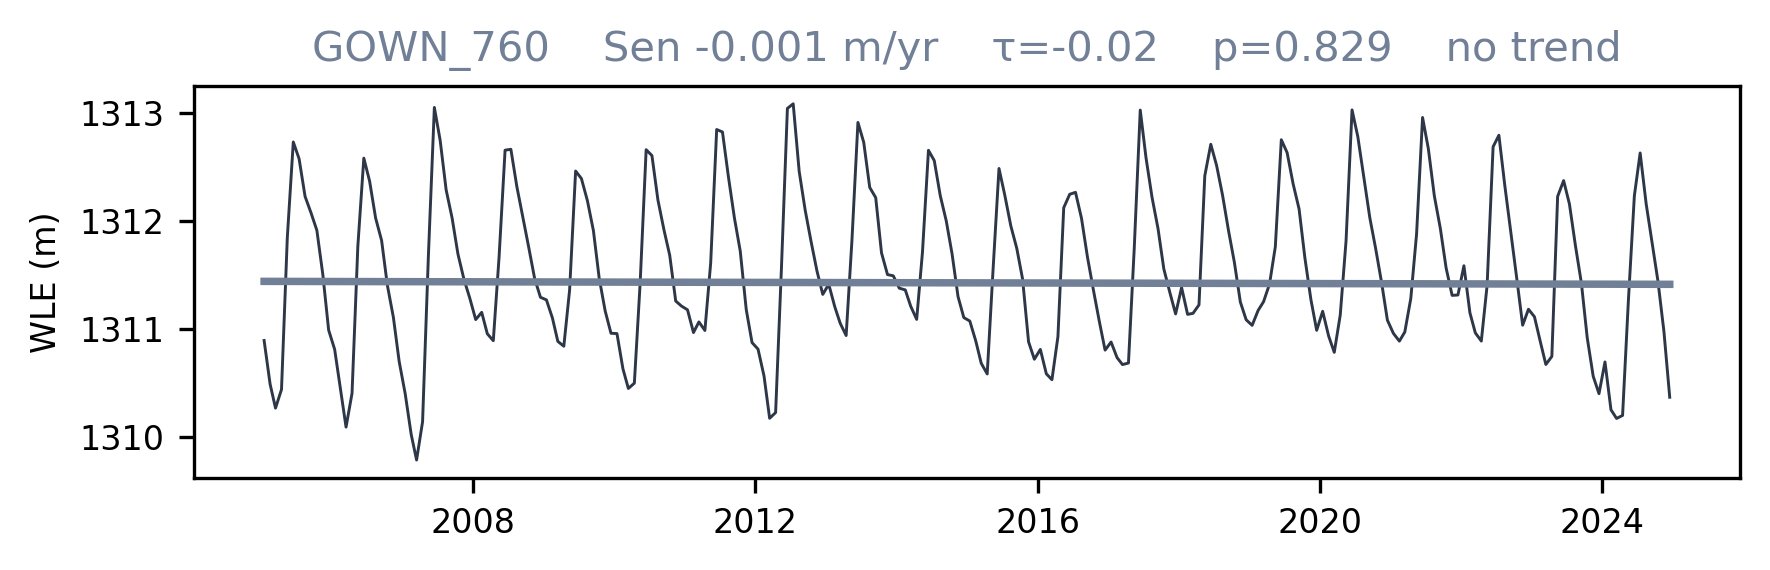

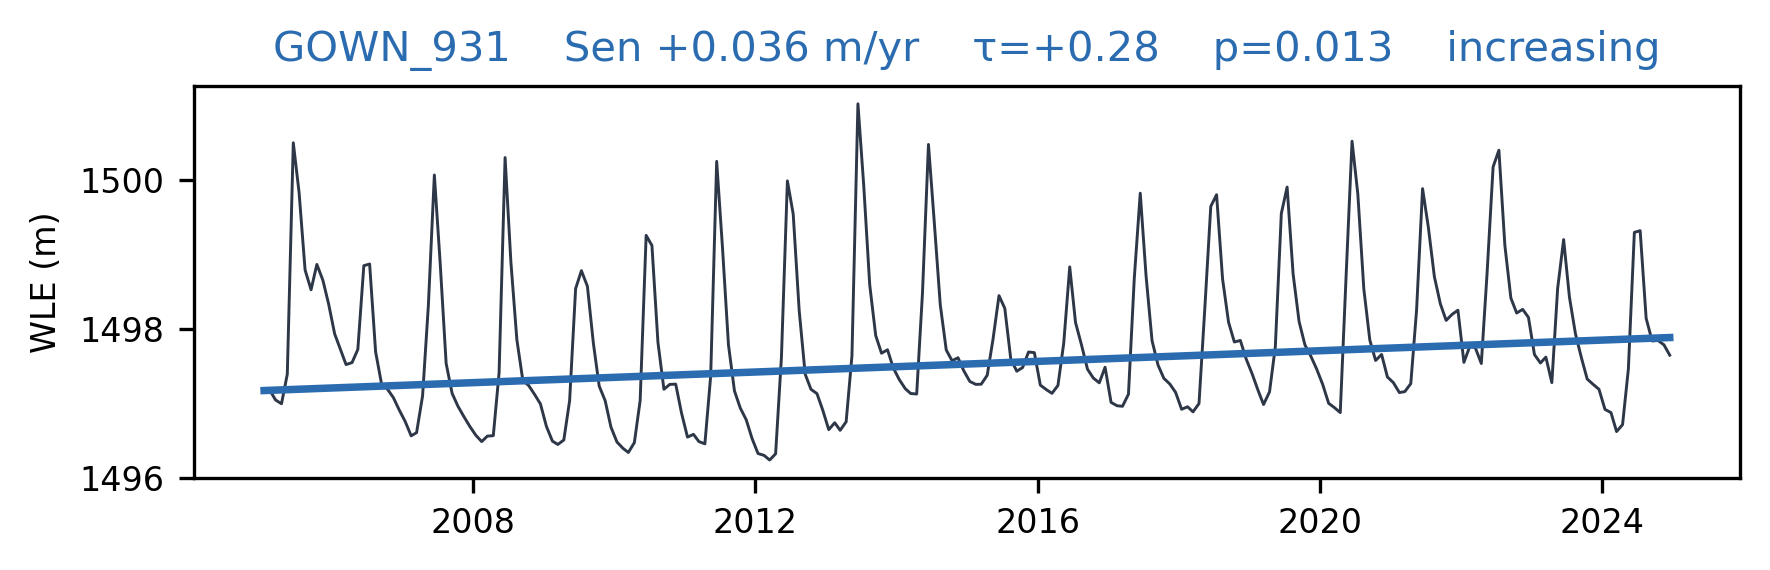

In [45]:
order = smk.sort_values("slope_m_yr").index          # declines first
tnum = np.arange(len(df_m))                          # month counter for the line
tmed = np.median(tnum)

vcolor = {"increasing": "#2b6cb0", "decreasing": "#c53030", "no trend": "#718096"}

for w in order:
    y = df_m[w]
    slope_mo = smk.loc[w, "slope_m_yr"] / 12       # back to per-month for plotting
    ymed = y.median()
    line = ymed + slope_mo * (tnum - tmed)         # Sen line through the median point

    v = smk.loc[w, "verdict"]
    fig, ax = plt.subplots(figsize=(6, 2), dpi=300)
    ax.plot(df_m.index, y, lw=0.7, color="#2d3748")
    ax.plot(df_m.index, line, lw=1.8, color=vcolor[v])

    ax.set_title(
        f"GOWN_{w}    Sen {smk.loc[w,'slope_m_yr']:+.3f} m/yr    "
        f"τ={smk.loc[w,'tau']:+.2f}    p={smk.loc[w,'p']:.3f}    {v}",
        fontsize=10, color=vcolor[v])
    ax.set_ylabel("WLE (m)", fontsize=8)
    ax.tick_params(labelsize=8)

    fig.tight_layout()
    plt.show()
    plt.close(fig)

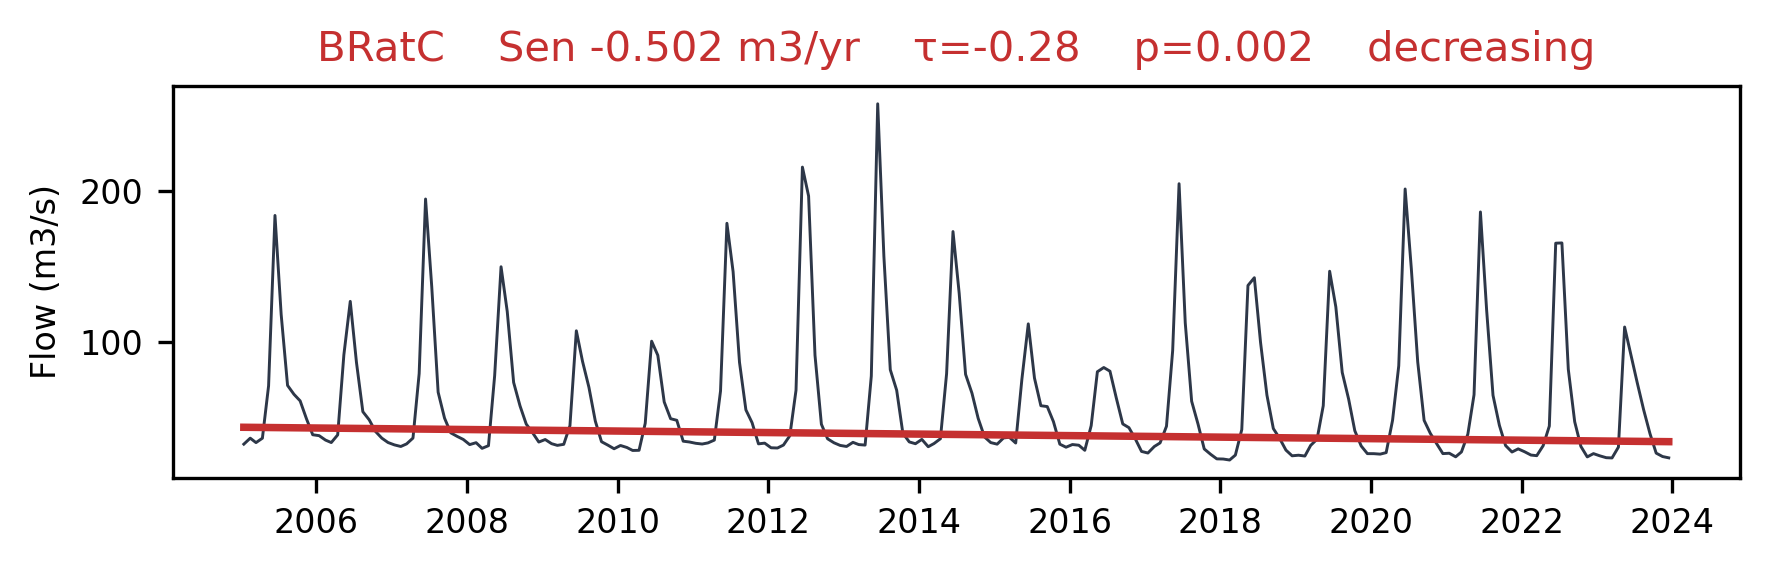

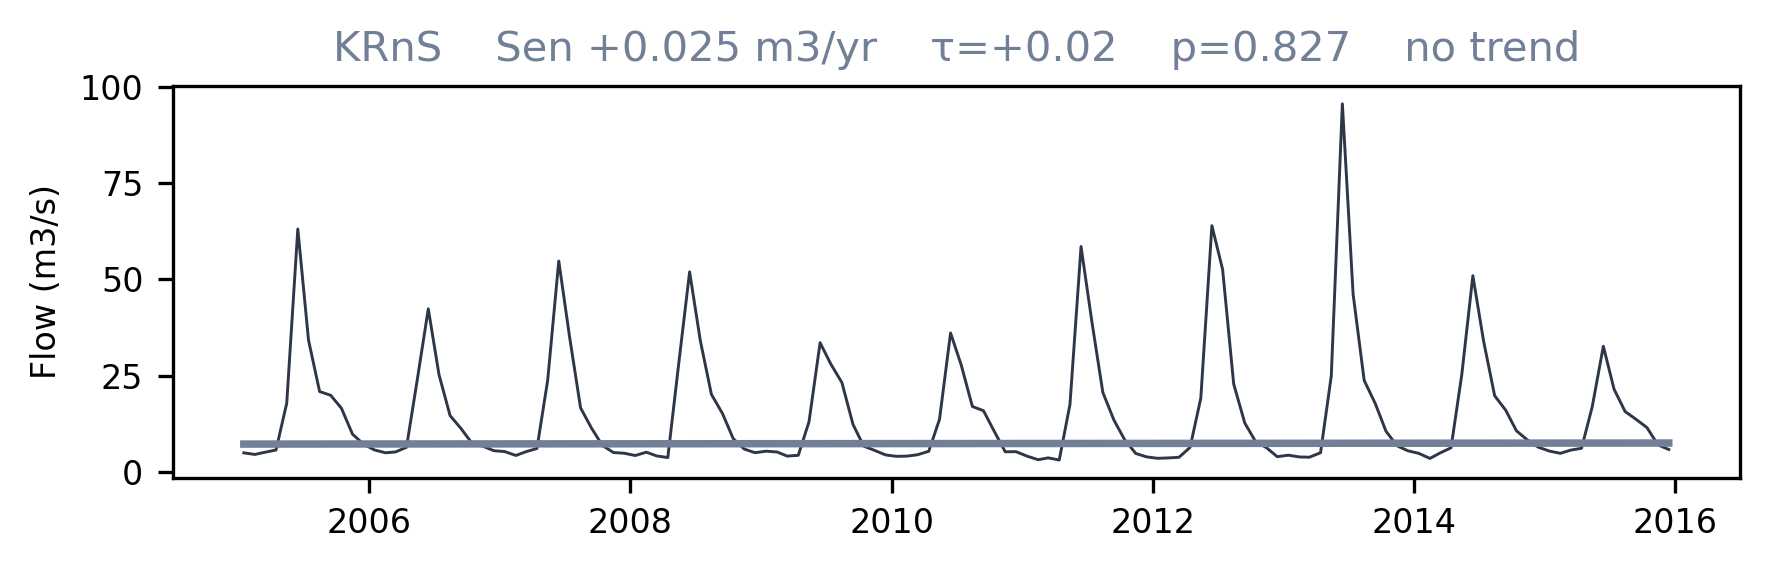

In [56]:
for riv, r in {'BRatC': brac, 'KRnS': krns}.items():
    tnum = np.arange(len(r))                          # month counter for the line
    tmed = np.median(tnum)

    y = r
    slope_mo = rivs.loc[riv, "slope_m3_yr"] / 12       # back to per-month for plotting
    ymed = y.median()
    line = ymed + slope_mo * (tnum - tmed)         # Sen line through the median point

    v = rivs.loc[riv, "verdict"]
    fig, ax = plt.subplots(figsize=(6, 2), dpi=300)
    ax.plot(y.index, y, lw=0.7, color="#2d3748")
    ax.plot(y.index, line, lw=1.8, color=vcolor[v])

    ax.set_title(
        f"{riv}    Sen {rivs.loc[riv, 'slope_m3_yr']:+.3f} m3/yr    "
        f"τ={rivs.loc[riv,'tau']:+.2f}    p={rivs.loc[riv,'p']:.3f}    {v}",
        fontsize=10, color=vcolor[v])
    ax.set_ylabel("Flow (m3/s)", fontsize=8)
    ax.tick_params(labelsize=8)

    fig.tight_layout()
    plt.show()
    plt.close(fig)

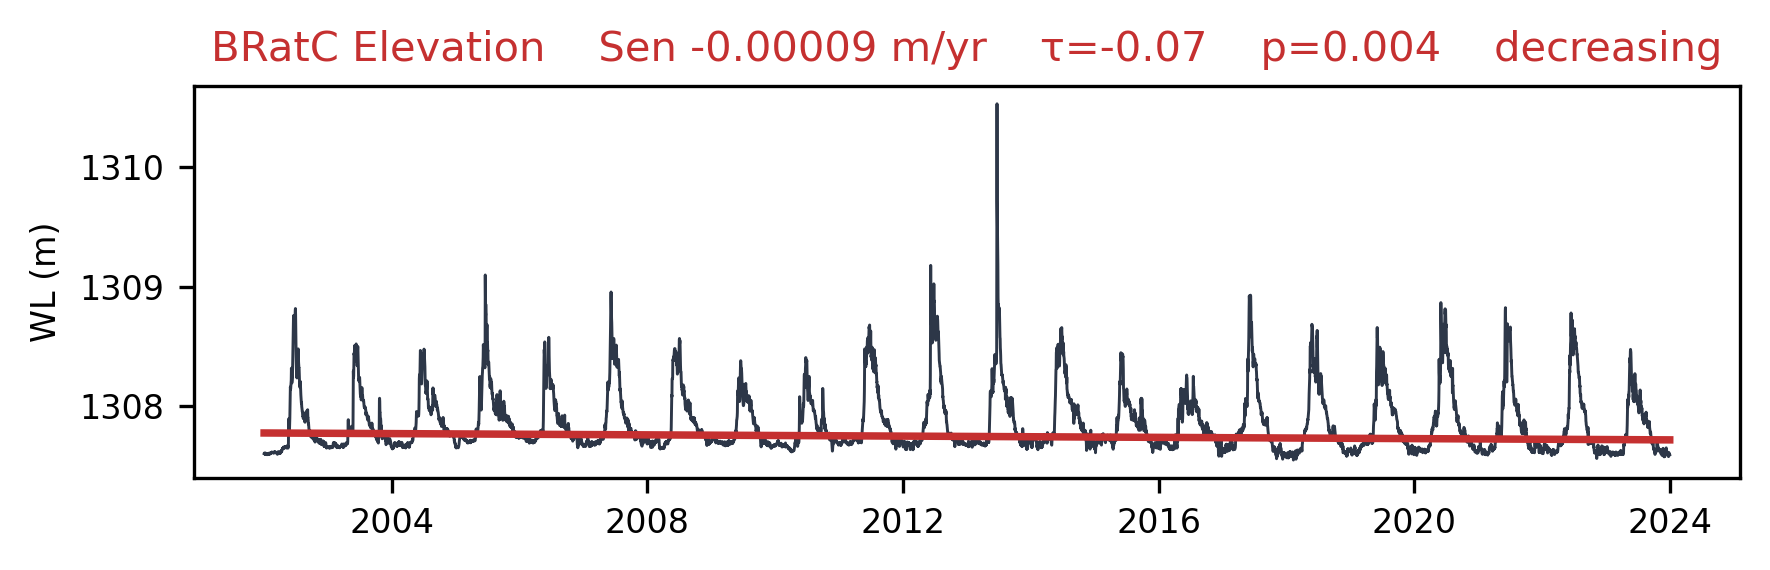

In [62]:
r = mk.correlated_seasonal_test(brac_e.values, period=12)

tnum = np.arange(len(brac_e))                          # month counter for the line
tmed = np.median(tnum)

slope_mo = r.slope / 12       # back to per-month for plotting
ymed = brac_e.median()
line = ymed + slope_mo * (tnum - tmed)         # Sen line through the median point

v = r.trend
fig, ax = plt.subplots(figsize=(6, 2), dpi=300)
ax.plot(brac_e.index, brac_e, lw=0.7, color="#2d3748")
ax.plot(brac_e.index, line, lw=1.8, color=vcolor[v])

ax.set_title(
    f"BRatC Elevation    Sen {r.slope:+.5f} m/yr    "
    f"τ={r.Tau:+.2f}    p={r.p:.3f}    {v}",
    fontsize=10, color=vcolor[v])
ax.set_ylabel("WL (m)", fontsize=8)
ax.tick_params(labelsize=8)

fig.tight_layout()
plt.show()
plt.close(fig)